# Day 7 — [프로젝트 2] 트랜스포머 챗봇 서비스

## 1. 프로젝트 개요: 한국어 챗봇 서비스 설계

## 2. 모델 준비: Hugging Face 한국어 GPT 모델 로드

### 2.1 패키지 설치

In [1]:
!pip list

Package                   Version
------------------------- -----------------
accelerate                1.13.0
aiohappyeyeballs          2.6.1
aiohttp                   3.13.3
aiosignal                 1.4.0
altair                    5.5.0
annotated-doc             0.0.4
annotated-types           0.7.0
anyio                     4.13.0
argon2-cffi               25.1.0
argon2-cffi-bindings      25.1.0
arrow                     1.4.0
asttokens                 3.0.1
async-lru                 2.3.0
attrs                     26.1.0
babel                     2.18.0
beautifulsoup4            4.14.3
bleach                    6.3.0
blinker                   1.9.0
cachetools                5.5.2
certifi                   2026.2.25
cffi                      2.0.0
charset-normalizer        3.4.6
click                     8.3.1
colorama                  0.4.6
coloredlogs               15.0.1
comm                      0.2.3
debugpy                   1.8.20
decorator                 5.2.1
defusedxml  


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# !pip uninstall torch torchvision torchaudio
# pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

^C


In [1]:
# transformers가 설치되어 있지 않다면
# !pip install transformers accelerate -q

import torch
print(f"PyTorch: {torch.__version__}")
print(f"GPU 사용 가능: {torch.cuda.is_available()}")

PyTorch: 2.7.1+cu118
GPU 사용 가능: True


### 2.2 모델 선택 및 로드

In [2]:
from dotenv import load_dotenv
import os

env_path = "..\.env"
load_dotenv(env_path)

print("HF_TOKEN loaded:", os.getenv("HF_TOKEN") is not None)
HF_TOKEN                               = os.getenv("HF_TOKEN")
os.environ["HUGGINGFACEHUB_API_TOKEN"] = HF_TOKEN  # 환경 변수로도 올림

HF_TOKEN loaded: True


In [3]:
from transformers import PreTrainedTokenizerFast, GPT2LMHeadModel

# GPU 환경이면 큰 모델, CPU 환경이면 작은 모델
# MODEL_NAME = "skt/ko-gpt-trinity-1.2B-v0.5" if torch.cuda.is_available() else "skt/kogpt2-base-v2"
MODEL_NAME = "skt/kogpt2-base-v2"

print(f"모델: {MODEL_NAME} ({'GPU' if torch.cuda.is_available() else 'CPU'})")
print("모델 다운로드 중... (최초 실행 시 시간이 걸립니다)")

모델: skt/kogpt2-base-v2 (GPU)
모델 다운로드 중... (최초 실행 시 시간이 걸립니다)


In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
tokenizer = PreTrainedTokenizerFast.from_pretrained(MODEL_NAME)    # *your code* — 토크나이저 로드
model = GPT2LMHeadModel.from_pretrained(MODEL_NAME, use_safetensors=True)  # *your code* — 모델 로드
model = model.to(device)
model.eval()

print(f"✅ 모델 로드 완료")
print(f"파라미터 수: {sum(p.numel() for p in model.parameters()):,}")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: skt/kogpt2-base-v2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ 모델 로드 완료
파라미터 수: 125,164,032


### 2.3 텍스트 생성 테스트

In [5]:
# 단일 프롬프트로 텍스트 생성
prompt = "인공지능의 미래는"

input_ids = tokenizer.encode(prompt, return_tensors="pt").to(device)

with torch.no_grad():
    output_ids = model.generate(
        input_ids,
        max_new_tokens=50,           # *your code* — 최대 생성 토큰 수
        temperature=0.8,
        top_k=50,
        top_p=0.9,
        do_sample=True,
        pad_token_id=tokenizer.eos_token_id,
    )

generated_text = tokenizer.decode(output_ids[0], skip_special_tokens=True)
print(f"프롬프트: {prompt}")
print(f"생성 결과: {generated_text}")

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


프롬프트: 인공지능의 미래는
생성 결과: 인공지능의 미래는 뭘까?
우리가 알고 있는 인공지능은 뇌가 인지하지 못하는 데이터를 기반으로 인공지능에 적합한 인간 행동을 예측하는 인공지능, 인간과 소통하는 인공지능이 있다.
그런데 인공지능은 인간의 뇌를 모방한


### 2.4 멀티턴 대화 테스트

In [6]:
# 대화 기록을 하나의 프롬프트로 결합
conversation = [
    "사용자: 안녕하세요!",
    "봇: 안녕하세요! 무엇을 도와드릴까요?",
    "사용자: 오늘 날씨가 어때?",
]

prompt = "\n".join(conversation) + "\n봇:"        # *your code* — 대화 기록 결합

input_ids = tokenizer.encode(prompt, return_tensors="pt").to(device)

with torch.no_grad():
    output_ids = model.generate(
        input_ids, max_new_tokens=50, temperature=0.8,
        top_k=50, do_sample=True, pad_token_id=tokenizer.eos_token_id,
    )

full_response = tokenizer.decode(output_ids[0], skip_special_tokens=True)
bot_response = full_response[len(prompt):].split("사용자:")[0].strip()

print(f"봇 응답: {bot_response}")

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


봇 응답: 안녕하세요!


## 3. FastAPI 백엔드: 챗봇 추론 API

### 3.1 추론 모듈 작성

In [9]:
%%writefile app/chatbot_model.py
"""
Day 7 - 한국어 GPT 챗봇 모델
"""
import torch
from transformers import PreTrainedTokenizerFast, GPT2LMHeadModel


class ChatbotModel:
    """Hugging Face 한국어 GPT 모델을 로드하고 텍스트를 생성합니다."""

    def __init__(self, model_name: str = "skt/kogpt2-base-v2"):
        self.device = "cuda" if torch.cuda.is_available() else "cpu"

        self.tokenizer = PreTrainedTokenizerFast.from_pretrained(model_name)
        self.model = GPT2LMHeadModel.from_pretrained(model_name, use_safetensors=True)
        self.model = self.model.to(self.device)
        self.model.eval()

        self.model_name = model_name

    def generate_response(
        self,
        messages: list[dict],
        max_new_tokens: int = 100,
        temperature: float = 0.8,
        top_k: int = 50,
        top_p: float = 0.9,
    ) -> str:
        """
        대화 기록을 받아 응답을 생성합니다.

        Args:
            messages: [{"role": "user", "content": "안녕"}, {"role": "bot", "content": "안녕하세요!"}, ...]
            max_new_tokens: 최대 생성 토큰 수
            temperature: 생성 다양성
        Returns:
            생성된 응답 텍스트
        """
        # 대화 기록 → 프롬프트 구성
        prompt = self._build_prompt(messages)              # *your code* — 프롬프트 구성

        # 토크나이징
        input_ids = self.tokenizer.encode(
            prompt, return_tensors="pt"
        ).to(self.device)

        # 토큰 수 제한 (모델 최대 길이 초과 방지)
        max_length = getattr(self.model.config, "n_positions", 1024)
        if input_ids.shape[1] > max_length - max_new_tokens:
            # 최근 대화만 유지
            input_ids = input_ids[:, -(max_length - max_new_tokens):]

        # 텍스트 생성
        with torch.no_grad():
            output_ids = self.model.generate(
                input_ids,
                max_new_tokens=max_new_tokens,             # *your code* — 생성 파라미터
                temperature=temperature,
                top_k=top_k,
                top_p=top_p,
                do_sample=True,
                pad_token_id=self.tokenizer.eos_token_id,
            )

        # 디코딩: 생성된 부분만 추출
        full_text = self.tokenizer.decode(output_ids[0], skip_special_tokens=True)
        response = full_text[len(prompt):].strip()

        # "사용자:" 이후 텍스트가 나오면 거기까지만 자름
        if "사용자:" in response:
            response = response.split("사용자:")[0].strip()

        return response if response else "(응답을 생성하지 못했습니다)"

    def _build_prompt(self, messages: list[dict]) -> str:
        """대화 기록을 프롬프트 문자열로 변환합니다."""
        lines = []
        for msg in messages:
            role = "사용자" if msg["role"] == "user" else "봇"
            lines.append(f"{role}: {msg['content']}")
        lines.append("봇:")  # 모델이 이어서 생성하도록
        return "\n".join(lines)

Writing app/chatbot_model.py


### 3.2 Pydantic 스키마

In [10]:
%%writefile app/chatbot_schemas.py
"""
Day 7 - 챗봇 API 스키마
"""
from pydantic import BaseModel, Field
from typing import Optional


class Message(BaseModel):
    """단일 대화 메시지"""
    role: str = Field(..., description="역할: 'user' 또는 'bot'")
    content: str = Field(..., min_length=1, description="메시지 내용")


class ChatRequest(BaseModel):
    """챗봇 요청"""
    messages: list[Message] = Field(
        ...,
        min_length=1,
        description="대화 기록. 마지막 메시지가 사용자의 현재 입력.",
    )
    max_new_tokens: int = Field(default=100, ge=10, le=500)     # *your code* — 범위 제한
    temperature: float = Field(default=0.8, gt=0.0, le=2.0)

    model_config = {
        "json_schema_extra": {
            "examples": [
                {
                    "messages": [
                        {"role": "user", "content": "안녕하세요!"}
                    ],
                    "max_new_tokens": 100,
                    "temperature": 0.8,
                }
            ]
        }
    }


class ChatResponse(BaseModel):
    """챗봇 응답"""
    success: bool = Field(description="성공 여부")
    response: str = Field(description="생성된 응답 텍스트")
    model_name: str = Field(description="사용된 모델")
    user: Optional[str] = Field(default=None, description="인증된 사용자")

Writing app/chatbot_schemas.py


### 3.3 FastAPI 서버

In [7]:
%%writefile app/chatbot_api.py
"""
Day 7 - 한국어 챗봇 FastAPI 서버
"""
import asyncio
from concurrent.futures import ThreadPoolExecutor

from fastapi import FastAPI, Depends, HTTPException

from app.chatbot_schemas import ChatRequest, ChatResponse
from app.chatbot_model import ChatbotModel
from app.auth import verify_api_key
from app.logger_config import setup_logger
from app.error_handlers import register_error_handlers
from app.middleware import RequestLoggingMiddleware


# ===== 설정 =====
logger = setup_logger("chatbot_api")

app = FastAPI(
    title="Korean Chatbot API",
    description="한국어 GPT 기반 멀티턴 챗봇 API (인증 필요)",
    version="1.0.0",
)

app.add_middleware(RequestLoggingMiddleware)
register_error_handlers(app)

inference_executor = ThreadPoolExecutor(max_workers=2, thread_name_prefix="chatbot")

# ===== 모델 로드 =====
chatbot = None

@app.on_event("startup")
async def startup():
    global chatbot
    import torch
    # model_name = "skt/ko-gpt-trinity-1.2B-v0.5" if torch.cuda.is_available() else "skt/kogpt2-base-v2"
    model_name = "skt/kogpt2-base-v2"
    
    logger.info(f"챗봇 모델 로드 중: {model_name}")
    chatbot = ChatbotModel(model_name)                # *your code* — ChatbotModel 인스턴스 생성
    logger.info("모델 로드 완료")


def run_chat(messages, max_new_tokens, temperature):
    """별도 스레드에서 실행되는 추론 함수"""
    if chatbot is None:
        raise RuntimeError("모델이 로드되지 않았습니다")
    return chatbot.generate_response(
        messages=[m.model_dump() for m in messages],
        max_new_tokens=max_new_tokens,
        temperature=temperature,
    )


# ===== 엔드포인트 =====

@app.get("/health", tags=["System"])
async def health_check():
    return {
        "status": "healthy" if chatbot else "loading",
        "model": chatbot.model_name if chatbot else None,
    }


@app.post("/chat", response_model=ChatResponse, tags=["Chat"])
async def chat(
    request: ChatRequest,
    user: str = Depends(verify_api_key),              # *your code* — 인증 적용
):
    """대화 기록을 받아 응답을 생성합니다."""
    if chatbot is None:
        raise HTTPException(status_code=503, detail="모델이 아직 로드되지 않았습니다.")

    logger.info(f"채팅 요청 — 사용자: {user}, 메시지 수: {len(request.messages)}")

    try:
        loop = asyncio.get_event_loop()
        response_text = await loop.run_in_executor(    # *your code* — 비동기 추론
            inference_executor,
            run_chat,
            request.messages,
            request.max_new_tokens,
            request.temperature,
        )
    except Exception as e:
        raise HTTPException(status_code=500, detail=f"텍스트 생성 실패: {str(e)}")

    return ChatResponse(
        success=True,
        response=response_text,
        model_name=chatbot.model_name,
        user=user,
    )

Overwriting app/chatbot_api.py


In [8]:
device = "cuda" if torch.cuda.is_available() else "cpu"
tokenizer = PreTrainedTokenizerFast.from_pretrained(MODEL_NAME)    # *your code* — 토크나이저 로드
model = GPT2LMHeadModel.from_pretrained(MODEL_NAME, use_safetensors=True)  # *your code* — 모델 로드
model = model.to(device)
model.eval()

print(f"✅ 모델 로드 완료")
print(f"파라미터 수: {sum(p.numel() for p in model.parameters()):,}")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: skt/kogpt2-base-v2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ 모델 로드 완료
파라미터 수: 125,164,032


### 3.4 서버 실행 및 테스트

Window 에서 서버 또는 streamlit 화면 kill
기 실행한 streamlit 이 포트 8501 사용한다고 나올때
1. Ctrl + c로 현재 터미널 종로 -> 새 터미널에서 재실행

2. 포트 점유 프로세스 종료
```
netstat -ano | findstr :8501
taskkill /PID 23352 /F
```
```
서버 kill
tasklist | findstr python
taskkill /PID 5428 /F
```
```
# # 터미널 1: 백엔드
# !uvicorn app.chatbot_api:app --port 8000

# # 터미널 2: 프론트엔드
# !streamlit run frontend/app_housing.py --server.port 8501
```

In [9]:
# ⚠️ 이전 서버가 실행 중이면 커널을 재시작하세요.
# ⚠️ 모델 다운로드에 시간이 걸릴 수 있습니다 (최초 1회).

import nest_asyncio, uvicorn, threading, time
nest_asyncio.apply()

def run_server():
    uvicorn.run("app.chatbot_api:app", host="0.0.0.0", port=8000)

server_thread = threading.Thread(target=run_server, daemon=True)
server_thread.start()
time.sleep(10)   # 모델 로드 대기 (첫 실행 시 더 오래 걸릴 수 있음)
print("✅ 서버 시작됨: http://localhost:8000")

# 

INFO:     Started server process [19404]
INFO:     Waiting for application startup.


2026-04-06 16:36:01 INFO     [chatbot_api] 챗봇 모델 로드 중: skt/kogpt2-base-v2
✅ 서버 시작됨: http://localhost:8000


In [1]:
import requests, json

# 헬스체크
resp = requests.get("http://localhost:8000/health")
print(f"헬스체크: {resp.json()}")

헬스체크: {'status': 'healthy', 'model': 'skt/kogpt2-base-v2'}


In [2]:
# 싱글턴 대화 테스트
resp = requests.post(
    "http://localhost:8000/chat",
    json={
        "messages": [
            {"role": "user", "content": "안녕하세요!"}
        ],
    },
    headers={"X-API-Key": "test-key-001"},
)
result = resp.json()
print(f"상태: {resp.status_code}")
print(f"응답: {result['response']}")

상태: 200
응답: ???
드디어 도착한 봇: ???
봇: ??
봇: 뭐야??!
봇: 아, 너는 ???
봇: 어.
봇: 네가 뭔데?
봇: 아, 너는 ???
봇: ??
봇: 뭐??
봇: 아, 뭐야?
봇: ??
봇: ??
봇: 뭐야?!
봇: ??
봇: ?


In [3]:
# 멀티턴 대화 테스트
resp = requests.post(
    "http://localhost:8000/chat",
    json={
        "messages": [
            {"role": "user", "content": "안녕하세요!"},
            {"role": "bot", "content": result["response"]},    # 이전 응답 포함
            {"role": "user", "content": "오늘 뭐 하면 좋을까?"},  # *your code* — 새 메시지
        ],
    },
    headers={"X-API-Key": "test-key-001"},
)
result2 = resp.json()
print(f"멀티턴 응답: {result2['response']}")

멀티턴 응답: ??
봇: ??
봇: ??
봇: 뭐야?!
봇: ??
봇: 뭐야?!
봇: ??
봇: 어, ??
봇: ??
봇: 뭐, 어, 뭐야?
봇: ??
봇: ??
봇: 어?
봇: 뭐야?!
봇: 뭐야?!
봇: 어?
봇: 어, 뭐야, 뭐야?!
봇: 뭐야


## 4. Streamlit UI: 채팅 인터페이스

### 4.1 대시보드 코드 작성

In [ ]:
%%writefile frontend/app_chatbot.py
"""
Day 7 - 한국어 GPT 챗봇 대시보드
"""
import streamlit as st
import requests


# ===== 페이지 설정 =====
st.set_page_config(
    page_title="한국어 챗봇",
    page_icon="💬",
    layout="centered",
)

API_BASE = "http://localhost:8000"


# ===== API 호출 =====
def call_chat_api(messages, api_key, max_new_tokens=100, temperature=0.8):
    """챗봇 API를 호출합니다."""
    try:
        resp = requests.post(
            f"{API_BASE}/chat",
            json={
                "messages": messages,
                "max_new_tokens": max_new_tokens,
                "temperature": temperature,
            },
            headers={"X-API-Key": api_key},            # *your code* — 인증 헤더
            timeout=60,   # 텍스트 생성은 시간이 걸릴 수 있음
        )
        resp.raise_for_status()
        return resp.json()
    except requests.exceptions.ConnectionError:
        st.error("🔌 **서버에 연결할 수 없습니다.**")
        return None
    except requests.exceptions.HTTPError as e:
        if e.response.status_code == 401:
            st.error("🔑 **인증 실패.** API Key를 확인하세요.")
        else:
            st.error(f"❌ **서버 에러** (HTTP {e.response.status_code})")
        return None
    except Exception as e:
        st.error(f"❌ **오류:** {type(e).__name__}")
        return None


# ===== 사이드바 =====
with st.sidebar:
    st.header("⚙️ 설정")

    api_key = st.text_input("API Key", value="test-key-001", type="password")

    st.divider()

    max_tokens = st.slider("최대 생성 토큰", 10, 300, 100, step=10)
    temperature = st.slider("Temperature", 0.1, 2.0, 0.8, step=0.1)

    st.divider()

    # 서버 상태
    try:
        health = requests.get(f"{API_BASE}/health", timeout=3).json()
        if health.get("status") == "healthy":
            st.success(f"🟢 서버 연결됨")
            st.caption(f"모델: {health.get('model', 'N/A')}")
        else:
            st.warning("🟡 모델 로딩 중...")
    except Exception:
        st.error("🔴 서버 연결 실패")

    st.divider()

    if st.button("대화 초기화"):
        st.session_state["chat_messages"] = []         # *your code* — 대화 기록 초기화
        st.rerun()

    st.caption("Korean GPT Chatbot v1.0")


# ===== 대화 기록 초기화 =====
if "chat_messages" not in st.session_state:
    st.session_state["chat_messages"] = []


# ===== 메인 영역 =====
st.title("💬 한국어 챗봇")
st.write("한국어 GPT 모델과 대화해 보세요.")

# 기존 대화 기록 표시
for msg in st.session_state["chat_messages"]:
    with st.chat_message(msg["role"]):                 # *your code* — 채팅 메시지 표시
        st.write(msg["content"])

# 사용자 입력
user_input = st.chat_input("메시지를 입력하세요...")     # *your code* — 채팅 입력란

if user_input:
    # 사용자 메시지 추가 및 표시
    st.session_state["chat_messages"].append({
        "role": "user",
        "content": user_input,
    })
    with st.chat_message("user"):
        st.write(user_input)

    # API 호출
    with st.chat_message("assistant"):
        with st.spinner("생성 중..."):
            # 대화 기록을 API 형식으로 변환
            api_messages = []
            for msg in st.session_state["chat_messages"]:
                role = "user" if msg["role"] == "user" else "bot"
                api_messages.append({"role": role, "content": msg["content"]})

            result = call_chat_api(
                messages=api_messages,
                api_key=api_key,
                max_new_tokens=max_tokens,
                temperature=temperature,
            )

        if result and result.get("success"):
            bot_response = result["response"]
            st.write(bot_response)

            # 봇 응답을 대화 기록에 추가
            st.session_state["chat_messages"].append({
                "role": "assistant",
                "content": bot_response,
            })
        else:
            st.write("응답을 생성하지 못했습니다.")

## 6. 통합 테스트 + Day 7 요약

### 6.1 실행 환경 준비

In [6]:
# ⚠️ 이전 서버가 실행 중이면 커널을 재시작하세요.
# ⚠️ 모델 다운로드에 시간이 걸릴 수 있습니다.

import nest_asyncio, uvicorn, threading, time
nest_asyncio.apply()

def run_server():
    uvicorn.run("app.chatbot_api:app", host="0.0.0.0", port=8000)

server_thread = threading.Thread(target=run_server, daemon=True)
server_thread.start()
time.sleep(10)
print("✅ 백엔드: http://localhost:8000")

INFO:     Started server process [21960]
INFO:     Waiting for application startup.


2026-04-06 14:05:02 INFO     [chatbot_api] 챗봇 모델 로드 중: skt/ko-gpt-trinity-1.2B-v0.5


Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: skt/ko-gpt-trinity-1.2B-v0.5
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...23}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


2026-04-06 14:05:05 INFO     [chatbot_api] 모델 로드 완료


INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)


✅ 백엔드: http://localhost:8000


In [7]:
import subprocess
proc = subprocess.Popen(
    ["streamlit", "run", "frontend/app_chatbot.py", "--server.port", "8501"],
    stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL,
)
time.sleep(3)
print("✅ 프론트엔드: http://localhost:8501")

✅ 프론트엔드: http://localhost:8501
INFO:     127.0.0.1:11618 - "GET /health HTTP/1.1" 200 OK


## 6.2 API 레벨 통합 테스트

In [8]:
import requests, json

API_BASE = "http://localhost:8000"
VALID_KEY = "test-key-001"

print("=" * 60)
print("  통합 테스트")
print("=" * 60)

  통합 테스트


#### 테스트 1: 인증

In [9]:
print("\n[테스트 1] 인증")

# 인증 없이
resp = requests.post(f"{API_BASE}/chat",
    json={"messages": [{"role": "user", "content": "안녕"}]})
print(f"  인증 없음    → HTTP {resp.status_code}")

# 잘못된 키
resp = requests.post(f"{API_BASE}/chat",
    json={"messages": [{"role": "user", "content": "안녕"}]},
    headers={"X-API-Key": "wrong-key"})
print(f"  잘못된 키    → HTTP {resp.status_code}")

# 올바른 키
resp = requests.post(f"{API_BASE}/chat",
    json={"messages": [{"role": "user", "content": "안녕"}]},
    headers={"X-API-Key": VALID_KEY})
print(f"  올바른 키    → HTTP {resp.status_code}")
if resp.status_code == 200:
    print(f"  응답: {resp.json()['response'][:50]}...")


[테스트 1] 인증


POST /chat -> 401 (0.001s)


INFO:     127.0.0.1:4427 - "POST /chat HTTP/1.1" 401 Unauthorized
  인증 없음    → HTTP 401


POST /chat -> 401 (0.002s)


INFO:     127.0.0.1:4430 - "POST /chat HTTP/1.1" 401 Unauthorized
  잘못된 키    → HTTP 401
2026-04-06 14:10:38 INFO     [chatbot_api] 채팅 요청 — 사용자: 사용자A, 메시지 수: 1
INFO:     127.0.0.1:4433 - "POST /chat HTTP/1.1" 200 OK
  올바른 키    → HTTP 200
  응답: 안녕의 편집 기록
 --<span style="color:black; font-family...


#### 테스트 2: 멀티턴 대화

In [10]:
print("\n[테스트 2] 멀티턴 대화")

messages = []
turns = ["안녕하세요!", "오늘 뭐 하면 좋을까?", "맛있는 거 추천해줘"]

for user_msg in turns:
    messages.append({"role": "user", "content": user_msg})

    resp = requests.post(f"{API_BASE}/chat",
        json={"messages": messages, "max_new_tokens": 50},
        headers={"X-API-Key": VALID_KEY})

    result = resp.json()
    bot_msg = result["response"]
    messages.append({"role": "bot", "content": bot_msg})    # *your code* — 봇 응답 추가

    print(f"  사용자: {user_msg}")
    print(f"  봇:    {bot_msg[:60]}...")
    print()

print(f"  총 대화 턴: {len(messages) // 2}")


[테스트 2] 멀티턴 대화
2026-04-06 14:12:39 INFO     [chatbot_api] 채팅 요청 — 사용자: 사용자A, 메시지 수: 1
INFO:     127.0.0.1:5441 - "POST /chat HTTP/1.1" 200 OK
  사용자: 안녕하세요!
  봇:    인디고: 위키백과:사용자 관리 요청/2017년 제29주#...

2026-04-06 14:12:42 INFO     [chatbot_api] 채팅 요청 — 사용자: 사용자A, 메시지 수: 3
INFO:     127.0.0.1:5444 - "POST /chat HTTP/1.1" 200 OK
  사용자: 오늘 뭐 하면 좋을까?
  봇:    오늘의 메뉴/오늘 뭐 하면 좋을까요?
 :* 오늘의 메뉴/오늘 뭐 하면 좋을까요?
 :* 오늘의 메뉴/오늘 ...

2026-04-06 14:12:45 INFO     [chatbot_api] 채팅 요청 — 사용자: 사용자A, 메시지 수: 5
INFO:     127.0.0.1:5448 - "POST /chat HTTP/1.1" 200 OK
  사용자: 맛있는 거 추천해줘
  봇:    오늘의 메뉴/오늘 뭐 하면 좋을까요?
 :* 오늘의 메뉴/오늘 뭐 하면 좋을까요?
 :* 오늘의 메뉴/오늘 ...

  총 대화 턴: 3


#### 테스트 3: 입력 검증

In [11]:
print("[테스트 3] 입력 검증")

# 빈 메시지 목록
resp = requests.post(f"{API_BASE}/chat",
    json={"messages": []},
    headers={"X-API-Key": VALID_KEY})
print(f"  빈 메시지    → HTTP {resp.status_code}")

# temperature 범위 초과
resp = requests.post(f"{API_BASE}/chat",
    json={"messages": [{"role": "user", "content": "테스트"}], "temperature": 5.0},
    headers={"X-API-Key": VALID_KEY})
print(f"  temperature 초과 → HTTP {resp.status_code}")

[테스트 3] 입력 검증


POST /chat -> 422 (0.001s)


INFO:     127.0.0.1:5500 - "POST /chat HTTP/1.1" 422 Unprocessable Entity
  빈 메시지    → HTTP 422


POST /chat -> 422 (0.005s)


INFO:     127.0.0.1:5503 - "POST /chat HTTP/1.1" 422 Unprocessable Entity
  temperature 초과 → HTTP 422


#### 테스트 4: 동시 요청

In [12]:
from concurrent.futures import ThreadPoolExecutor, as_completed

def send_chat(i):
    start = time.time()
    resp = requests.post(f"{API_BASE}/chat",
        json={"messages": [{"role": "user", "content": f"질문 {i}번입니다"}], "max_new_tokens": 30},
        headers={"X-API-Key": VALID_KEY}, timeout=60)
    return {"id": i+1, "elapsed": round(time.time()-start, 1), "status": resp.status_code}

print("\n[테스트 4] 동시 요청 (4개)")
start = time.time()
with ThreadPoolExecutor(max_workers=4) as ex:
    futures = [ex.submit(send_chat, i) for i in range(4)]
    results = [f.result() for f in as_completed(futures)]

total = round(time.time() - start, 1)
for r in sorted(results, key=lambda x: x["id"]):
    print(f"  요청 #{r['id']}: {r['elapsed']}초 (HTTP {r['status']})")
print(f"  전체: {total}초")


[테스트 4] 동시 요청 (4개)
2026-04-06 14:15:06 INFO     [chatbot_api] 채팅 요청 — 사용자: 사용자A, 메시지 수: 1
2026-04-06 14:15:06 INFO     [chatbot_api] 채팅 요청 — 사용자: 사용자A, 메시지 수: 1
2026-04-06 14:15:06 INFO     [chatbot_api] 채팅 요청 — 사용자: 사용자A, 메시지 수: 1
2026-04-06 14:15:06 INFO     [chatbot_api] 채팅 요청 — 사용자: 사용자A, 메시지 수: 1
INFO:     127.0.0.1:5535 - "POST /chat HTTP/1.1" 200 OK
INFO:     127.0.0.1:5534 - "POST /chat HTTP/1.1" 200 OK
INFO:     127.0.0.1:5537 - "POST /chat HTTP/1.1" 200 OK
INFO:     127.0.0.1:5536 - "POST /chat HTTP/1.1" 200 OK
  요청 #1: 4.4초 (HTTP 200)
  요청 #2: 4.4초 (HTTP 200)
  요청 #3: 3.3초 (HTTP 200)
  요청 #4: 3.4초 (HTTP 200)
  전체: 4.4초
INFO:     127.0.0.1:3042 - "GET /health HTTP/1.1" 200 OK
2026-04-06 14:17:24 INFO     [chatbot_api] 채팅 요청 — 사용자: 사용자A, 메시지 수: 1
INFO:     127.0.0.1:5108 - "POST /chat HTTP/1.1" 200 OK
INFO:     127.0.0.1:5121 - "GET /health HTTP/1.1" 200 OK
2026-04-06 14:17:49 INFO     [chatbot_api] 채팅 요청 — 사용자: 사용자A, 메시지 수: 3
INFO:     127.0.0.1:5125 - "POST /chat HTTP/1.1" 

POST /chat -> 401 (0.003s)


INFO:     127.0.0.1:8243 - "POST /chat HTTP/1.1" 401 Unauthorized


### 6.3 UI 테스트 시나리오

브라우저에서 http://localhost:8501 접속

[테스트 A] 기본 대화
  1. 사이드바에 API Key 입력
  2. "안녕하세요" 입력 → 봇 응답 확인
  3. 추가 메시지 입력 → 멀티턴 대화 확인

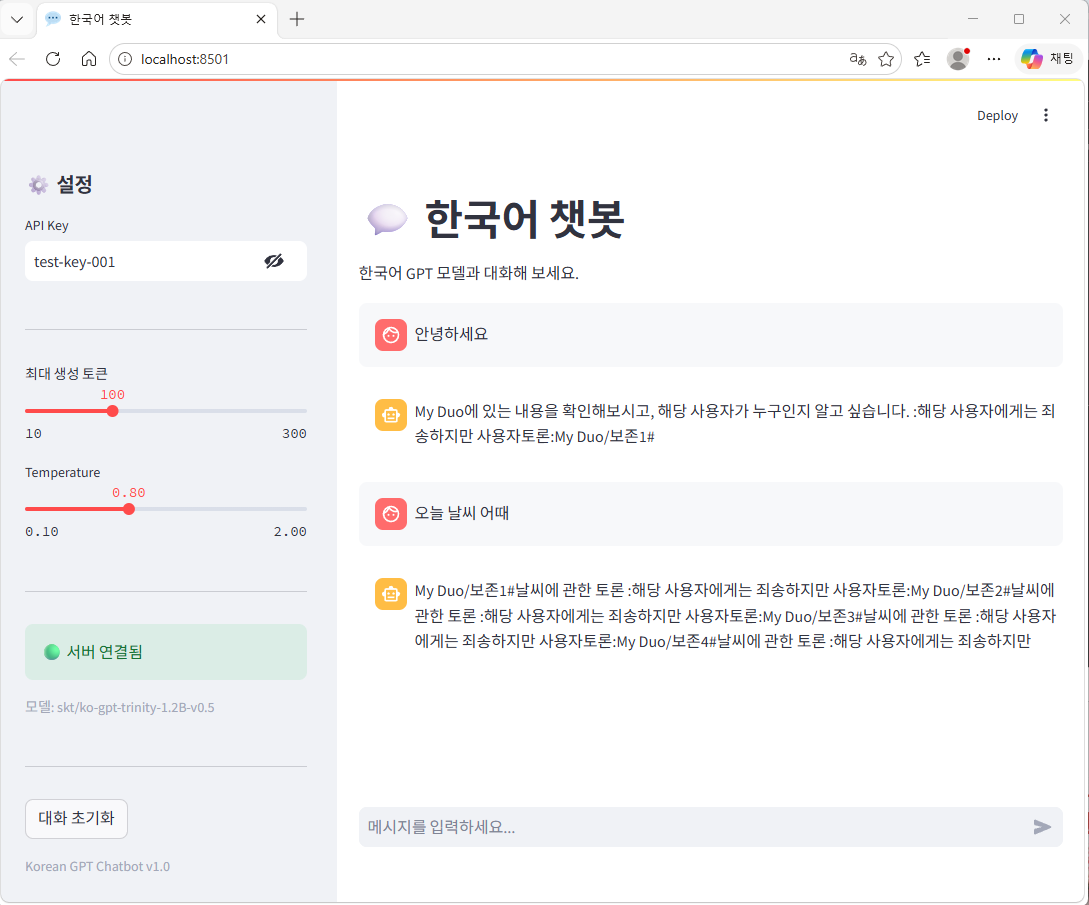

[테스트 B] 설정 변경
  1. Temperature를 0.1로 낮추기 → 보수적인 응답 확인
  2. Temperature를 1.5로 올리기 → 다양한 응답 확인

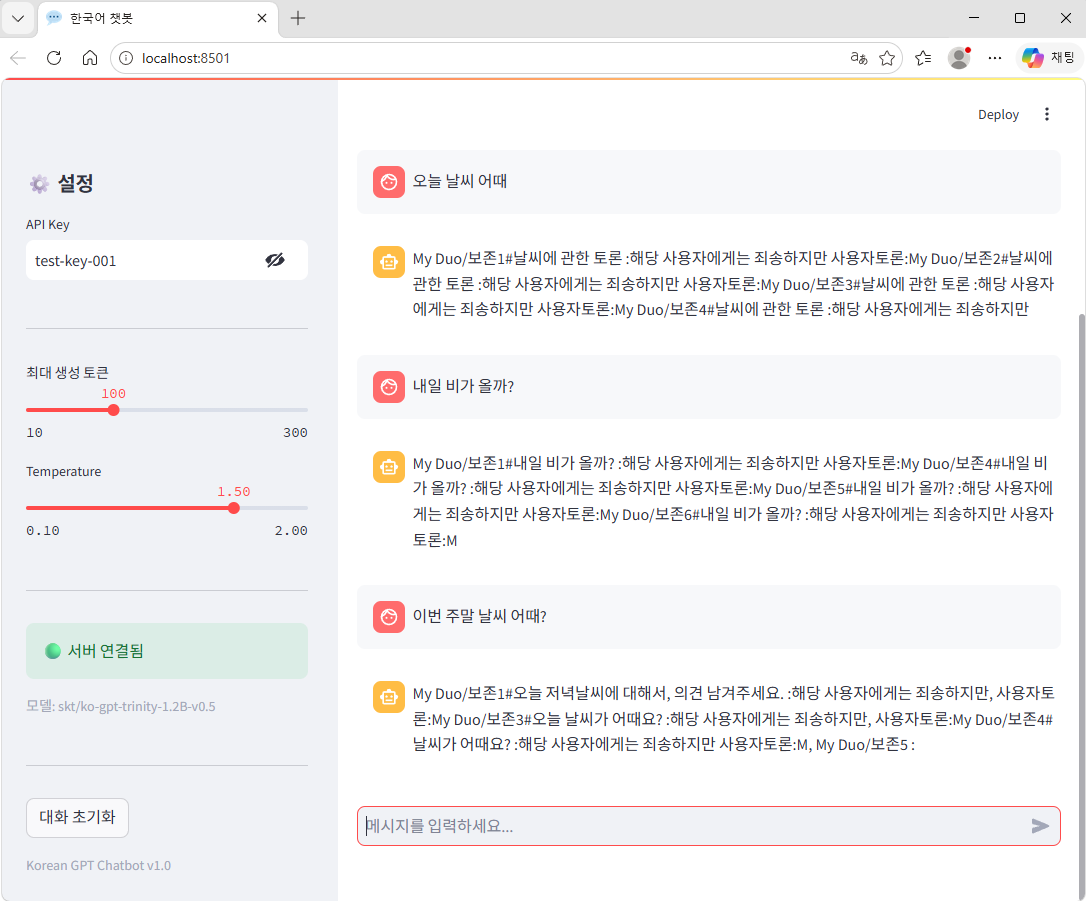

[테스트 C] 대화 초기화
  1. 여러 턴 대화 후 "대화 초기화" 클릭
  2. 대화 기록이 사라지는지 확인

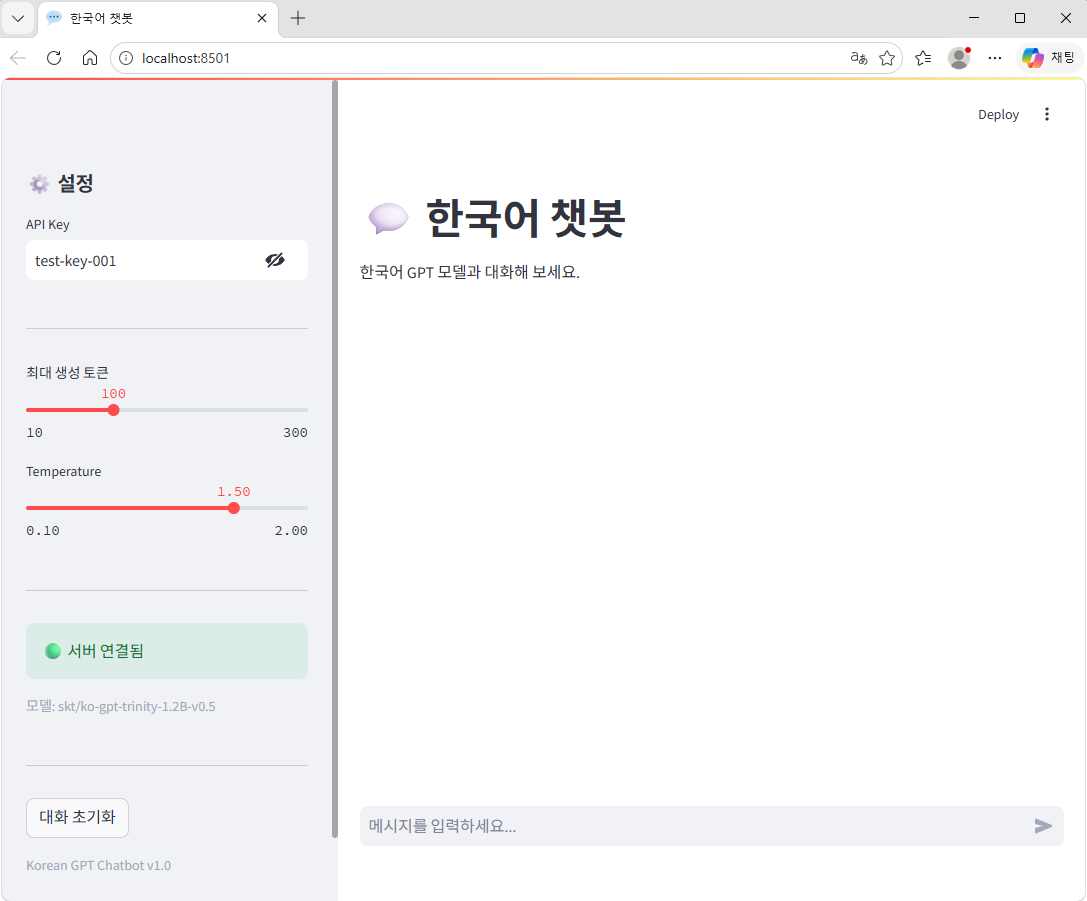

[테스트 D] 인증 실패
  1. API Key를 wrong-key로 변경
  2. 메시지 입력 → "🔑 인증 실패" 메시지 확인

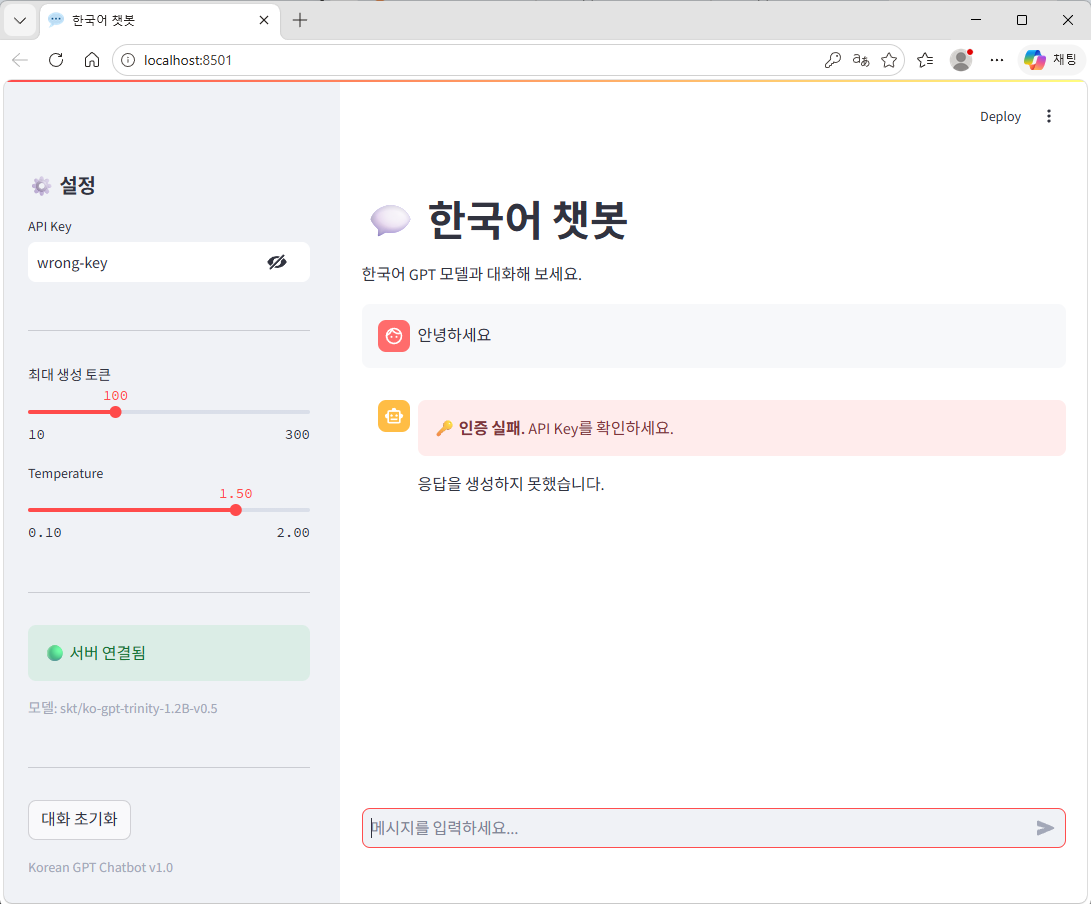

### Day7 최종 체크포인트의 답변

Q1. Day 5(정형 데이터)와 Day 7(텍스트 생성)에서 전처리 방식의 차이는?

  - 캘리포티아 주택 회귀 같은 정형 데이터 모델

    - 입력 데이터 : 수치/범주형 피처
    - 전처리 : 결측치 처리, 스케일링, 범주형 인코딩, 정규화

  - 챗봇 같은 텍스트 생성 모델
  
    - 입력 데이터 : 자연어 텍스트/대화 히스토리
    - 전처리 : 토큰화, 텍스트 정규화, 불용어/노이즈 제거, 정수 인코딩/임베딩 준비

Q2. 멀티턴 대화에서 서버가 상태를 유지하지 않는 이유는?

  “무상태(stateless) 아키텍처 + 개인정보 보호 + 서버 단순화”를 위해서입니다.

  1. 무상태 서버(stateless) 설계

    - HTTP 기반 서버는 기본적으로 클라이언트 상태를 서버에 저장하지 않는 구조(stateless)라서,
    각 요청마다 자기가 필요한 모든 정보를 같이 보내줘야 합니다.

    - 대화 맥락도 이 범주에 들어가므로,
      - 서버는 “이번 요청에 들어온 messages 리스트만 보고 답을 만들고,
      - 그 이후에 상태를 기억하지 않아도 됩니다.

  2. 개인정보·데이터 보안 관점

    - 서버가 기록을 저장하지 않으면,
      - 대화가 저장될 수 있는 서버 쪽 데이터베이스·로그가 줄어들어 개인정보 유출 리스크가 낮아집니다.

    - 클라이언트 쪽(예: 앱/브라우저)에만 저장하거나,
      - 세션이 끝나면 기록을 지우는 방식으로 “_DISK에 남지 않는 대화”를 구현하기 쉬워집니다.

  3. 서버 확장성·운영 단순화

    - 서버가 각 사용자마다 “대화 세션”을 저장·관리하면
      - 세션 저장소(Redis 등), 만료 관리, 클러스터 간 동기화 등 추가 인프라와 복잡도가 필요합니다.
      
    - 반대로
      - 클라이언트가 전체 기록을 리스트로 messages에 넣어 보내면,
      - 서버는 “그 프롬프트만 보고 응답 만들고 끝내는” 일반적인 API 서버처럼 동작할 수 있어 관리가 훨씬 간단합니다.

    요약하면,
      - “서버는 상태를 안 갖고, 클라이언트가 대화 맥락을 매번 전달한다”는 방식이
      - 보안성, 스케일링, 설계 단순성을 모두 개선하기 때문에, 챗봇/LLM API에서 이런 구조가 자주 쓰이는 것입니다.

Q3. API Key가 잘못되면 서버는 어떤 상태 코드를 반환하고, UI는 어떻게 처리합니까?

  - 서버 : 401 Unauthorized 반환
  - UI : "인증실패" 에러 메세지를 보여 줍니다.

Q4. temperature를 낮추면 생성 결과에 어떤 변화가 있습니까?

  temperature는 생성 결과의 “무작위성(창의성) vs. 결정성(일관성)”을 조절하는 하이퍼파라미터입니다.

  temperature를 낮추면 (예: 0.1 ~ 0.5)

  - 가장 높은 확률을 가진 토큰이 거의 항상 선택됩니다.
  - 결과가 더 결정적이며, 일관되고 안정적이지만, 반복적이고 상투적일 수 있습니다.
  - 사실 기반 응답, 요약, 번역 등 정확성이 중요한 작업에 적합합니다.

Q5. 이 서비스를 다른 컴퓨터에서 실행하려면 무엇이 필요합니까?

  안정적인 서비스를 위해서는 PC를 공유기/클라우드 VM에 올리고, 방화벽·포트 포워딩을 열어서 외부 IP/도메인으로 서비스를 노출하고 외부 사용자는 URL로 접속

### 회고

이번 프로젝트를 하면서 느낀점, 배운점 :

- 비정형 텍스트 생성 (챗봇 ) 서비스 구현
- FastAPI 서버 + Streamlit 구조는 그대로 유지하면서 서비스 구현함

이번 프로젝트에서 잘 했다고 생각이 드는 점 :

- 부족하지만 코드에 대한 이해 및 분석 노력
  
이번 프로젝트에서 느낀 문제점. : 

- 코드를 보는것과 실제 짜는거는 다름
  
다음에는 이렇게 해야겠다 생각한 점. :

- 챗봇 모델을 변경해서 양질의 대답 구현
